                   N      Min    Median       Max  Ret mean (%)  Ret sd (%)  \
Instrument                                                                    
XAU Curncy      7806  252.550  1189.385  5417.210         0.031       1.050   
XAG Curncy      7804    4.060    16.050   116.697         0.034       1.921   
DXY Curncy      7787   71.329    94.650   120.900         0.002       0.474   
EURUSD Curncy   7807    0.827     1.165     1.599        -0.001       0.572   
USDJPY Curncy   7826   75.820   111.760   161.690         0.005       0.642   
USGG10YR Index  7820    0.507     3.770     7.062        -0.006       2.278   
CL1 Comdty      7538  -37.630    59.200   145.290         0.005       4.614   
HG1 Comdty      7537   60.600   279.550   663.550         0.023       1.712   
VIX Index       7575    9.140    18.600    82.690        -0.001       6.989   

                Ann. vol (%)    Skew  Ex. kurt Transform  
Instrument                                                
XAU Curncy  

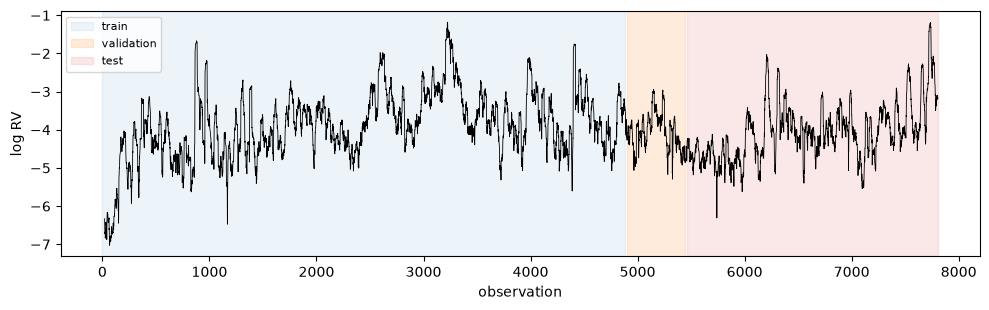

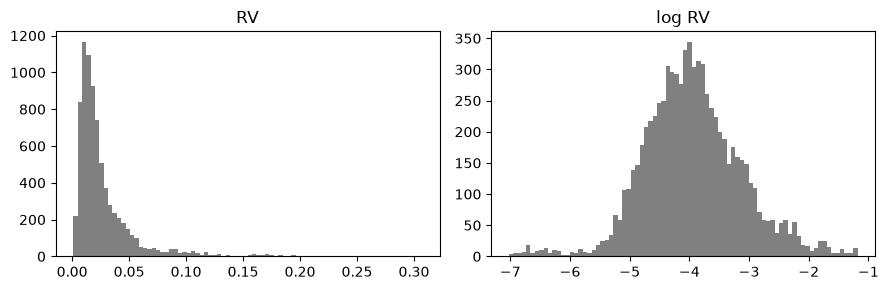

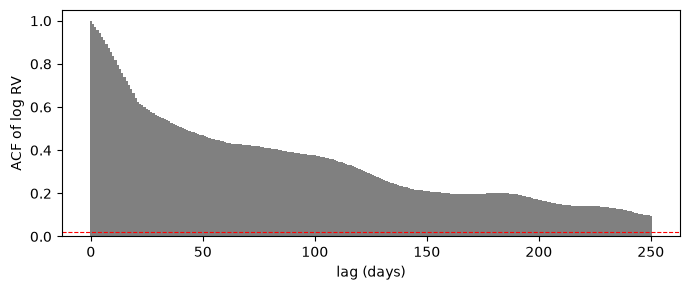

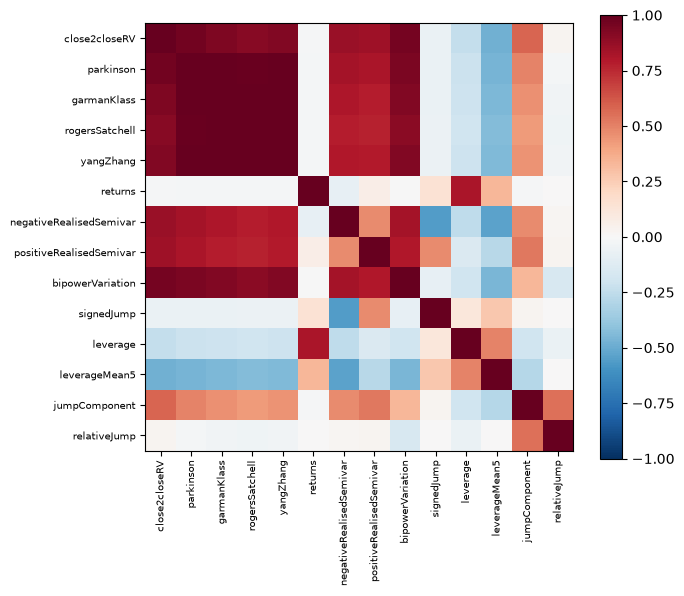

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

con  = sqlite3.connect("blp.db")
SECS = ["XAU Curncy","XAG Curncy","DXY Curncy","EURUSD Curncy","USDJPY Curncy",
        "USGG10YR Index","CL1 Comdty","HG1 Comdty","VIX Index"]

# ---------- Table 1: raw price level + daily return, per instrument ----------
rows = []
for s in SECS:
    px = pd.read_sql("SELECT date, value FROM blp_data WHERE security=? AND field='PX_LAST' "
                     "ORDER BY date", con, params=(s,))["value"]
    r  = np.log(px).diff() if (px > 0).all() else px.pct_change()
    r  = r.dropna()
    rows.append({
        "Instrument": s, "N": len(px),
        "Min": px.min(), "Median": px.median(), "Max": px.max(),
        "Ret mean (%)": 100*r.mean(), "Ret sd (%)": 100*r.std(),
        "Ann. vol (%)": 100*r.std()*np.sqrt(252),
        "Skew": r.skew(), "Ex. kurt": r.kurt(),
        "Transform": "log" if (px > 0).all() else "pct",
    })
tbl1 = pd.DataFrame(rows).set_index("Instrument").round(3)
tbl1.to_csv("tbl_instruments.csv"); print(tbl1, "\n")

# ---------- Table 2: engineered features, XAU ----------
df = pd.read_sql("SELECT * FROM prep_data WHERE security='XAU Curncy' ORDER BY date", con)
feat = ["close2closeRV","parkinson","garmanKlass","rogersSatchell","yangZhang","returns",
        "negativeRealisedSemivar","positiveRealisedSemivar","bipowerVariation",
        "signedJump","leverage","leverageMean5","jumpComponent","relativeJump"]
tbl2 = pd.DataFrame({
    "N":     df[feat].count(),
    "NaN":   df[feat].isna().sum(),
    "Mean":  df[feat].mean(), "SD": df[feat].std(),
    "Min":   df[feat].min(),  "Max": df[feat].max(),
    "Skew":  df[feat].skew(), "Ex. kurt": df[feat].kurt(),
}).round(5)
tbl2.to_csv("tbl_features.csv"); print(tbl2, "\n")

# ---------- the log-normality argument ----------
rv, lrv = df.close2closeRV.dropna(), np.log(df.close2closeRV.dropna())
print(f"RV      skew {rv.skew():6.3f}  ex.kurt {rv.kurt():7.3f}")
print(f"log RV  skew {lrv.skew():6.3f}  ex.kurt {lrv.kurt():7.3f}")

# ---------- Figures ----------
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(lrv.index, lrv.values, lw=0.6, color="black")
ax.axvspan(0, 4879, alpha=.08, color="tab:blue",   label="train")
ax.axvspan(4900, 5443, alpha=.15, color="tab:orange", label="validation")
ax.axvspan(5464, len(df), alpha=.10, color="tab:red", label="test")
ax.set_ylabel("log RV"); ax.set_xlabel("observation"); ax.legend(loc="upper left", fontsize=8)
fig.tight_layout(); fig.savefig("fig_target_splits.png", dpi=200)

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].hist(rv, bins=80, color="grey"); axes[0].set_title("RV")
axes[1].hist(lrv, bins=80, color="grey"); axes[1].set_title("log RV")
fig.tight_layout(); fig.savefig("fig_log_transform.png", dpi=200)

x = (lrv - lrv.mean()).values
acf = np.array([1.0] + [np.corrcoef(x[:-k], x[k:])[0,1] for k in range(1, 251)])
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(251), acf, width=1.0, color="grey")
ax.axhline(1.96/np.sqrt(len(x)), ls="--", lw=.8, color="red")
ax.set_xlabel("lag (days)"); ax.set_ylabel("ACF of log RV")
fig.tight_layout(); fig.savefig("fig_acf.png", dpi=200)

C = df[feat].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feat))); ax.set_xticklabels(feat, rotation=90, fontsize=7)
ax.set_yticks(range(len(feat))); ax.set_yticklabels(feat, fontsize=7)
fig.colorbar(im); fig.tight_layout(); fig.savefig("fig_corr.png", dpi=200)